![BSC AI Factory — Document Anonymization — Module 2](assets/headers/document-anonymization.jpg)

# 01. Document anonymization

**Topic: Module 2 · Walkthrough: Module 8, slide 3**

Replace identifying values in a two-page synthetic PDF while preserving its layout. PyMuPDF extracts text positions, Presidio detects sensitive spans, and Faker generates replacements.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer.


## Setup

Use a fresh **Python 3.11** environment. The next cell installs missing packages and corrects version mismatches.
If it installs anything, restart the kernel, then run all cells in order. Results are saved under `generated/`.


In [1]:
import subprocess
import sys
from importlib.metadata import version, PackageNotFoundError

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        "This pinned course pack requires Python 3.11. Select a Python 3.11 kernel before installing packages."
    )

REQUIRED = {
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "scipy": "1.13.1",
    "scikit-learn": "1.5.0",
    "matplotlib": "3.9.4",
    "pymupdf": "1.25.5",
    "presidio-analyzer": "2.2.358",
    "spacy": "3.7.5",
    "Faker": "37.1.0",
}


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


missing = [
    f"{name}=={wanted}"
    for name, wanted in REQUIRED.items()
    if installed_version(name) != wanted
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
    raise RuntimeError("Setup finished. Restart the kernel/runtime, then Run All.")
print("Dependencies ready:", {name: version(name) for name in REQUIRED})

Dependencies ready: {'numpy': '1.26.4', 'pandas': '2.2.3', 'scipy': '1.13.1', 'scikit-learn': '1.5.0', 'matplotlib': '3.9.4', 'pymupdf': '1.25.5', 'presidio-analyzer': '2.2.358', 'spacy': '3.7.5', 'Faker': '37.1.0'}


In [2]:
if installed_version("en-core-web-sm") != "3.7.1":
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl",
        ]
    )
print("English NLP model ready.")

English NLP model ready.


In [3]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)

import datetime
import re
import pymupdf as fitz
from faker import Faker
from presidio_analyzer import AnalyzerEngine, Pattern, PatternRecognizer
from presidio_analyzer.nlp_engine import NlpEngineProvider

OUTPUT_DIR = Path("generated/01_document")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Create a document with known identifiers

All values below are synthetic. The second page repeats the name, email and member ID so we can
check that the replacements stay consistent across pages. We know the original values and can
check that none remain in the saved PDF.


In [4]:
PAGES = [
    [
        ("Name", "Daniel Foster"),
        ("Email", "daniel.foster@example.com"),
        ("Phone", "(415) 555-0142"),
        ("Social Security Number", "534-21-9087"),
        ("Credit Card", "4111 1111 1111 1111"),
        ("IP Address", "192.168.24.17"),
        ("IBAN", "GB29 NWBK 6016 1331 9268 19"),
        ("Member ID", "ACT-778215"),
        ("Signup Date", "March 3, 2024"),
    ],
    [
        ("Name", "Daniel Foster"),
        ("Email", "daniel.foster@example.com"),
        ("Member ID", "ACT-778215"),
        ("Address", "14 Example Road, Boston, MA 02108"),
    ],
]
source_pdf, replacement_pdf = (
    OUTPUT_DIR / "record_original.pdf",
    OUTPUT_DIR / "record_replaced.pdf",
)
with fitz.open() as doc:
    for page_index, fields in enumerate(PAGES, 1):
        page = doc.new_page(width=660, height=500)
        page.draw_rect(fitz.Rect(0, 0, 660, 14), color=None, fill=(0.11, 0.19, 0.46))
        page.insert_text(
            (48, 58),
            "ACME CLOUD",
            fontsize=19,
            fontname="hebo",
            color=(0.11, 0.19, 0.46),
        )
        page.insert_text((48, 84), "Account record - synthetic example", fontsize=12)
        for i, (label, value) in enumerate(fields):
            y = 130 + i * 32
            page.insert_text((48, y), label + ":", fontsize=11)
            page.insert_text((245, y), value, fontsize=11)
        page.insert_text(
            (48, 476),
            f"Course example  |  Page {page_index} of {len(PAGES)}",
            fontsize=9,
        )
    doc.save(source_pdf, garbage=4, deflate=True)
print("Created", source_pdf)

Created generated/01_document/record_original.pdf


## 2. Detect values and map them to page positions

The NLP model supplies general recognizers. We also register patterns for this form's known labels.
These patterns select the complete value, including multiword names and addresses. Overlapping hits
are resolved before any redactions are applied. A new form needs its own field rules and review.


In [5]:
nlp_config = {
    "nlp_engine_name": "spacy",
    "models": [{"lang_code": "en", "model_name": "en_core_web_sm"}],
}
nlp_engine = NlpEngineProvider(nlp_configuration=nlp_config).create_engine()
analyzer = AnalyzerEngine(nlp_engine=nlp_engine, supported_languages=["en"])

FIELD_TYPES = {
    "Name": "PERSON",
    "Email": "EMAIL_ADDRESS",
    "Phone": "PHONE_NUMBER",
    "Social Security Number": "US_SSN",
    "Credit Card": "CREDIT_CARD",
    "IP Address": "IP_ADDRESS",
    "IBAN": "IBAN_CODE",
    "Member ID": "MEMBER_ID",
    "Signup Date": "DATE_TIME",
    "Address": "LOCATION",
}
for label, entity_type in FIELD_TYPES.items():
    pattern = Pattern("complete " + label, rf"(?<=\A{re.escape(label)}: ).+", 1.0)
    recognizer = PatternRecognizer(supported_entity=entity_type, patterns=[pattern])
    analyzer.registry.add_recognizer(recognizer)


def row_text_and_positions(words):
    """Join words left to right and keep each word's character range and PDF box."""
    text = ""
    positions = []
    for word in sorted(words, key=lambda word: word[0]):
        if text:
            text += " "
        start = len(text)
        text += word[4]
        positions.append((start, len(text), fitz.Rect(word[:4])))
    return text, positions


def select_value_hits(hits, value_start):
    """Prefer confident, longer detections; exclude labels and overlapping hits."""
    ranked_hits = sorted(
        hits, key=lambda hit: (-hit.score, -(hit.end - hit.start), hit.start)
    )
    selected = []
    for hit in ranked_hits:
        overlaps = any(hit.start < old.end and old.start < hit.end for old in selected)
        if hit.start >= value_start and not overlaps:
            selected.append(hit)
    return selected


def detect_page(page):
    # This form has aligned single-line fields. Group words by their bottom edge.
    rows = {}
    for word in page.get_text("words"):
        rows.setdefault(round(word[3], 1), []).append(word)

    text_spans = []
    for block in page.get_text("dict")["blocks"]:
        for line in block.get("lines", []):
            text_spans.extend(line["spans"])

    detections = []
    for words in rows.values():
        text, positions = row_text_and_positions(words)
        label, separator, expected_value = text.partition(": ")
        if not separator or label not in FIELD_TYPES:
            continue

        hits = analyzer.analyze(text=text, language="en", entities=[FIELD_TYPES[label]])
        selected = select_value_hits(hits, value_start=len(label) + 2)
        for hit in selected:
            boxes = [
                box
                for start, end, box in positions
                if start < hit.end and end > hit.start
            ]
            value_box = fitz.Rect(boxes[0])
            for box in boxes[1:]:
                value_box.include_rect(box)

            # Keep the original baseline and font size when inserting the replacement.
            matching_span = next(
                span
                for span in text_spans
                if fitz.Rect(span["bbox"]).intersects(value_box)
                and abs(span["origin"][0] - value_box.x0) < 1
            )
            detections.append(
                {
                    "box": value_box,
                    "value": text[hit.start : hit.end],
                    "entity": hit.entity_type,
                    "origin": matching_span["origin"],
                    "size": matching_span["size"],
                }
            )
        assert (
            len(selected) == 1
            and text[selected[0].start : selected[0].end] == expected_value
        ), label
    return detections


with fitz.open(source_pdf) as document:
    page_detections = [
        (index, detect_page(page)) for index, page in enumerate(document)
    ]

detection_rows = []
for page_index, detections in page_detections:
    for detection in detections:
        detection_rows.append(
            {
                "page": page_index + 1,
                "type": detection["entity"],
                "synthetic original": detection["value"],
            }
        )
display(pd.DataFrame(detection_rows))

,page,type,synthetic original
0,1,PERSON,Daniel Foster
1,1,EMAIL_ADDRESS,daniel.foster@example.com
2,1,PHONE_NUMBER,(415) 555-0142
3,1,US_SSN,534-21-9087
4,1,CREDIT_CARD,4111 1111 1111 1111
5,1,IP_ADDRESS,192.168.24.17
6,1,IBAN_CODE,GB29 NWBK 6016 1331 9268 19
7,1,MEMBER_ID,ACT-778215
8,1,DATE_TIME,"March 3, 2024"
9,2,PERSON,Daniel Foster


## 3. Generate and apply replacements

A mapping kept in memory gives repeated values the same replacement. The demo uses a fixed seed
to make its figures reproducible; the seed is not derived from an identifier. Each page is redacted
once, then all replacements are inserted at their original baselines. A fit check rejects text
that cannot be placed legibly. The output is saved as a new, cleaned PDF.


In [6]:
fake = Faker("en_US")
fake.seed_instance(41)


def fake_signup_date():
    start = datetime.date(2010, 1, 1)
    end = datetime.date(2025, 1, 1)
    return fake.date_between_dates(start, end).strftime("%B %d, %Y")


generators = {
    "PERSON": fake.name,
    "EMAIL_ADDRESS": fake.ascii_safe_email,
    "PHONE_NUMBER": lambda: fake.numerify("(202) 555-01##"),
    "US_SSN": fake.ssn,
    "CREDIT_CARD": lambda: fake.credit_card_number(card_type="visa"),
    "IP_ADDRESS": lambda: "192.0.2." + str(fake.random_int(1, 254)),
    "IBAN_CODE": fake.iban,
    "MEMBER_ID": lambda: "ACT-" + fake.numerify("######"),
    "DATE_TIME": fake_signup_date,
    "LOCATION": lambda: fake.address().replace("\n", ", "),
}
original_values = {
    detection["value"] for _, detections in page_detections for detection in detections
}
replacement_map = {}
used_replacements = set()


def make_distinct_replacement(entity_type):
    for _ in range(100):
        candidate = generators[entity_type]()
        if candidate not in original_values and candidate not in used_replacements:
            return candidate
    raise ValueError("Could not create a distinct replacement")


# Generate one replacement for each unique (type, original value) pair.
for _, detections in page_detections:
    for detection in detections:
        key = (detection["entity"], detection["value"])
        if key not in replacement_map:
            replacement = make_distinct_replacement(detection["entity"])
            replacement_map[key] = replacement
            used_replacements.add(replacement)

replacement_font_sizes = []
with fitz.open(source_pdf) as document:
    for page_index, detections in page_detections:
        page = document[page_index]

        # Remove all original values before inserting any replacements.
        for detection in detections:
            page.add_redact_annot(detection["box"], fill=(1, 1, 1))
        page.apply_redactions(images=0, graphics=0)

        for detection in detections:
            value = replacement_map[(detection["entity"], detection["value"])]
            original_size = detection["size"]
            available_width = page.rect.width - 48 - detection["origin"][0]
            text_width = fitz.get_text_length(
                value, fontname="helv", fontsize=original_size
            )
            font_size = min(
                original_size, original_size * available_width / max(text_width, 1)
            )
            assert font_size >= 9, "Replacement needs a wider field or a shorter value."
            page.insert_text(
                detection["origin"], value, fontsize=font_size, fontname="helv"
            )
            replacement_font_sizes.append(font_size)

    document.set_metadata({})
    document.del_xml_metadata()
    document.save(replacement_pdf, garbage=4, deflate=True, clean=True)

field_count = sum(len(detections) for _, detections in page_detections)
print("Replaced", field_count, "fields across", len(page_detections), "pages.")

Replaced 13 fields across 2 pages.


## 4. Check the rewritten file

Reopen the PDF and check its text, field labels, page count and rendered pages. Replacing identifiers
this way is a form of pseudonymization; it does not prove that any document processed this way is anonymous.
This example handles aligned text fields in a digital PDF. Scanned pages, attachments and complex
layouts need additional handling.


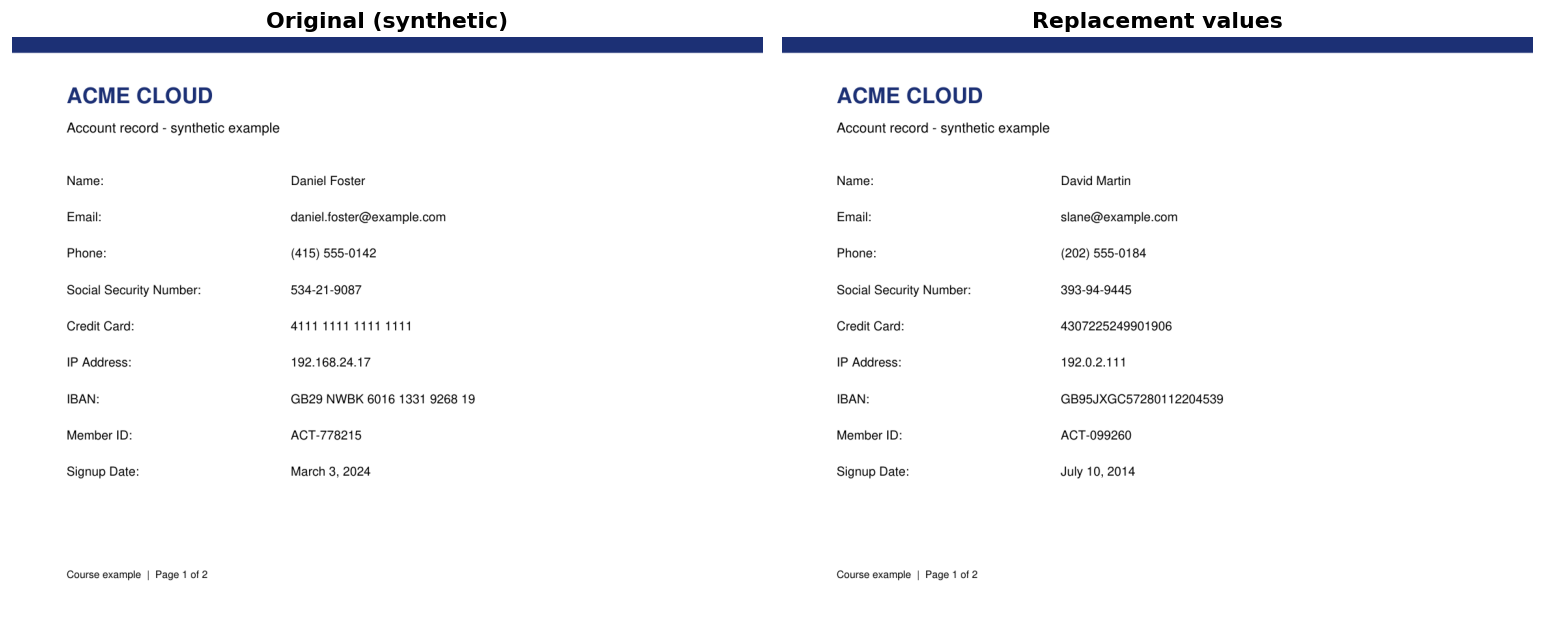

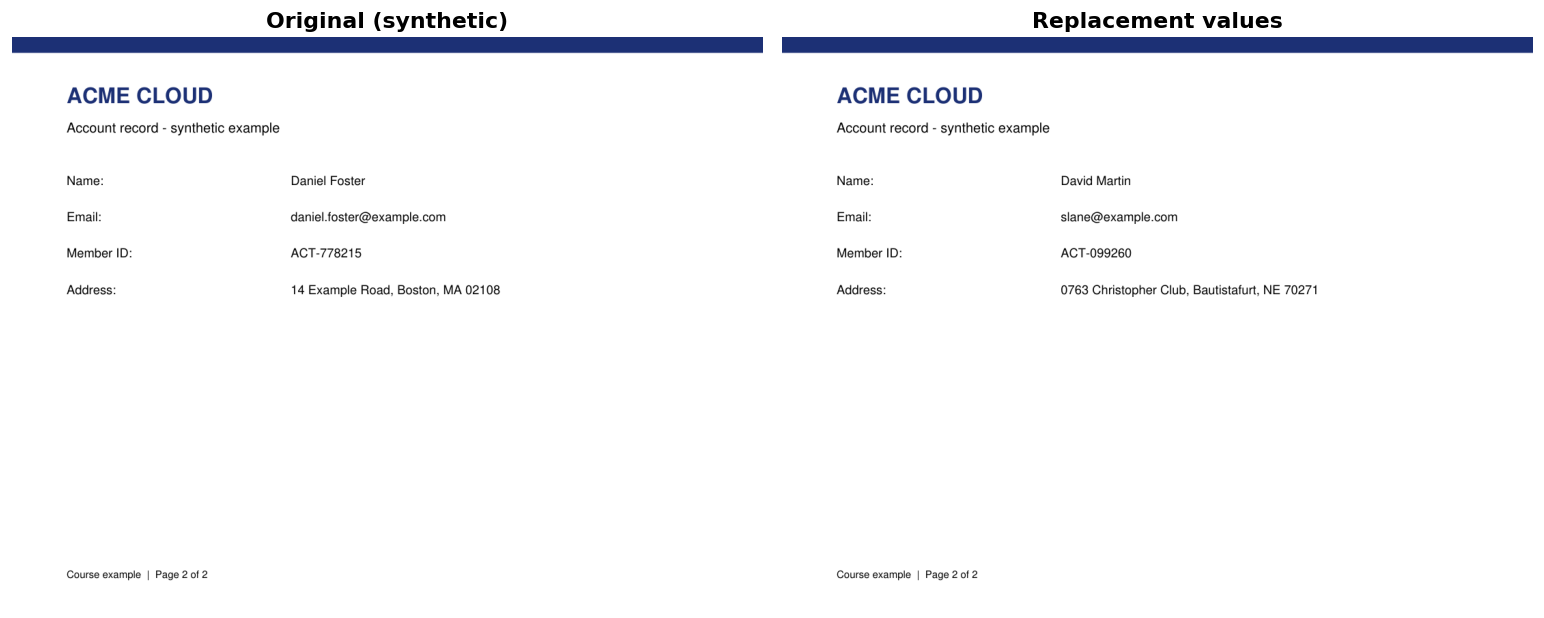

All fixture checks passed.


In [7]:
def render_page(doc, index):
    pixmap = doc[index].get_pixmap(dpi=120, alpha=False)
    return np.frombuffer(pixmap.samples, dtype=np.uint8).reshape(
        pixmap.height, pixmap.width, 3
    )


with fitz.open(source_pdf) as before, fitz.open(replacement_pdf) as after:
    assert len(before) == len(after) == len(PAGES)
    text_after = "\n".join(p.get_text() for p in after)
    assert all(value not in text_after for value in original_values)
    assert all(value in text_after for value in replacement_map.values())
    for page_index, fields in enumerate(PAGES):
        assert before[page_index].rect == after[page_index].rect
        assert all(label + ":" in after[page_index].get_text() for label, _ in fields)
        for label, value in fields:
            assert (
                replacement_map[(FIELD_TYPES[label], value)]
                in after[page_index].get_text()
            )
        fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
        for ax, doc, title in zip(
            axes, [before, after], ["Original (synthetic)", "Replacement values"]
        ):
            ax.imshow(render_page(doc, page_index))
            ax.set_title(title)
            ax.axis("off")
        fig.tight_layout()
        fig.savefig(
            OUTPUT_DIR / f"before_after_page_{page_index+1}.png", bbox_inches="tight"
        )
        plt.show()
summary = {
    "pages": len(PAGES),
    "fields_replaced": sum(map(len, PAGES)),
    "unique_replacements": len(replacement_map),
    "original_values_remaining": 0,
    "minimum_font_size": min(replacement_font_sizes),
}
(OUTPUT_DIR / "checks.json").write_text(json.dumps(summary, indent=2))
print("All fixture checks passed.")

## Experiments

1. Add a second synthetic person and run all cells again.
2. Repeat a value on both pages and confirm it receives the same replacement.
3. Add a new field label, its recognizer and its replacement generator; update the fixture checks.

Documentation: [PyMuPDF redactions](https://pymupdf.readthedocs.io/en/latest/page.html#Page.apply_redactions),
[Presidio analyzer](https://microsoft.github.io/presidio/analyzer/), [Faker](https://faker.readthedocs.io/).
